# Prepare data

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
from IPython.display import display

In [2]:
# read the new dataframe
crime_count_df = pd.read_csv("crime_count_df.csv")
crime_count_df['crime date'] = pd.to_datetime(crime_count_df['crime date'])  # convert to datetime
crime_count_df.set_index('crime date', inplace=True)           # make date the index
crime_count_df = crime_count_df.asfreq('D')                              # ensure daily frequency

# Check for missing dates (NaNs may appear if any days are missing)
crime_count_df = crime_count_df.fillna(0)
warnings.filterwarnings('ignore')

## Split Dataset

In [3]:
crime_count_df = crime_count_df.reset_index()

# the train dataset is from the beginning of January 2020 until the beginning of October 2024
train = crime_count_df[crime_count_df['crime date'] < '2024-10-01']
test = crime_count_df[crime_count_df['crime date'] >= '2024-10-01']


In [4]:
train.set_index('crime date', inplace=True)
test.set_index('crime date', inplace=True)

# Model Planning/Building

In [5]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")
# ====== 1. Scale Data ======
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(np.array(train).reshape(-1, 1))
test_scaled = scaler.transform(np.array(test).reshape(-1, 1))

In [6]:
# ====== 2. Create Dataset Function ======
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 12  # use last 12 points to predict the next one
X_train, y_train = create_dataset(train_scaled, time_step)

# Reshape for LSTM: (samples, time steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

In [7]:
# ====== 3. Build LSTM Model ======
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [8]:
# ====== 4. Train Model ======
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

In [9]:
# ====== 5. Prepare Test Data ======
# Combine last part of train + test for proper sequences
past_data = train_scaled[-time_step:]
test_input = np.concatenate((past_data, test_scaled), axis=0)
X_test, y_test = create_dataset(test_input, time_step)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [10]:
# ====== 6. Forecast ======
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)

# Align predictions with test dates
pred_index = test.index
pred_series = pd.Series(pred.flatten(), index=pred_index)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step


In [11]:
# ====== 7. Evaluate ======
mae = mean_absolute_error(test, pred_series)
rmse = np.sqrt(mean_squared_error(test, pred_series))
print(f"LSTM → MAE: {mae:.2f}, RMSE: {rmse:.2f}")


LSTM → MAE: 24.19, RMSE: 30.67


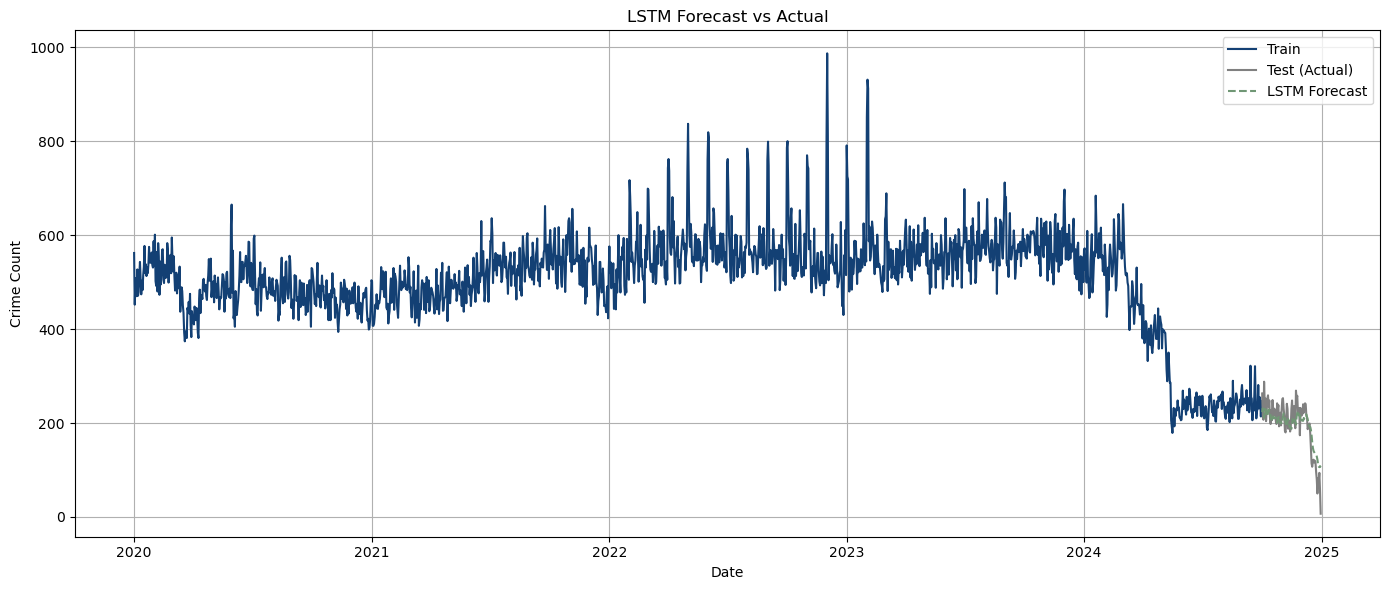

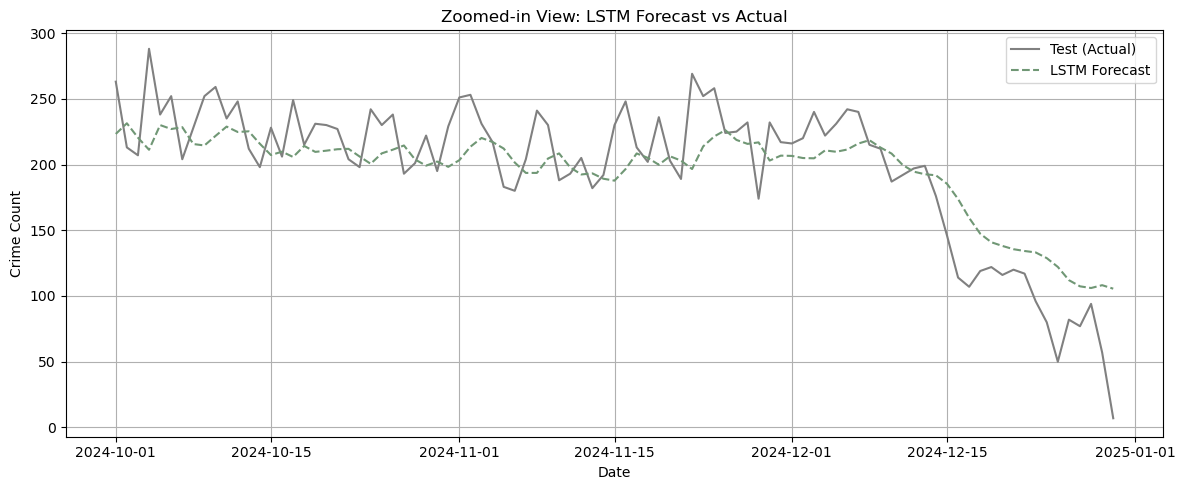

In [12]:
# ====== 8. Plot ======
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Train', color='#134074')
plt.plot(test.index, test, label='Test (Actual)', color='gray')
plt.plot(pred_index, pred_series, label='LSTM Forecast', color='#709775', linestyle='dashed')

plt.title('LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Test (Actual)', color='gray')
plt.plot(pred_index, pred_series, label='LSTM Forecast', color='#709775', linestyle='dashed')

plt.title('Zoomed-in View: LSTM Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Crime Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()